# Titanic Survival — Model Results

Every evaluation figure in the project, reproduced from the trained artifacts.

The companion notebook [`eda.ipynb`](eda.ipynb) explains the **data**. This one reports the
**results**: it loads the four trained models from `artifacts/`, recreates the held-out
validation split, re-scores every model from scratch, and draws every figure.

**Three things make this notebook trustworthy rather than decorative:**

1. **Nothing is hard-coded.** Every number below is computed from the saved model weights and
   the dataset. Retrain and re-run, and the figures change with the results.
2. **The figures come from `titanic.plots`** — the exact functions `train.py` saves as HTML and
   the Streamlit app renders. There is no second plotting implementation to drift.
3. **The reproduction is checked, not claimed.** Section 2 asserts that the metrics recomputed
   here match `artifacts/<model>/metrics.json` to 10 decimal places. If the split, the
   preprocessor or the weights had drifted, this notebook would fail rather than mislead.

**Headline:** on 179 held-out passengers a **34-parameter logistic regression matches a
7,361-parameter transformer**. Every model's confidence interval overlaps every other's.

In [1]:
from __future__ import annotations

import json
import warnings

import numpy as np
import pandas as pd
import plotly.io as pio

from titanic import plots
from titanic.artifacts import available_models, bundle_dir, load_bundle, load_registry
from titanic.config import TARGET_COLUMN, Paths, SplitConfig
from titanic.data import load_csv, stratified_split
from titanic.evaluation import bootstrap_ci, compute_metrics, curve_data
from titanic.features import engineer
from titanic.utils import set_seed

# Static PNG rendering: Plotly's interactive output does not display on GitHub,
# and these figures should be readable without running anything. Everything is
# still a real Plotly figure -- swap to "notebook" below for interactivity.
pio.renderers.default = "png"

set_seed(42)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

paths = Paths()
registry = load_registry(paths.registry)
MODELS = available_models(paths.artifacts)

print(f"artifacts: {paths.artifacts}")
print(f"models   : {', '.join(MODELS)}")
print(f"default  : {registry.get('default')}")

artifacts: C:\projects\hw1_titanic\artifacts
models   : fast, deep, gbdt, attn
default  : deep


---

## 1. What was trained

Each bundle carries its own architecture config, its own fitted preprocessor, and the metrics
from its single held-out evaluation.

In [2]:
rows = []
for name in MODELS:
    directory = bundle_dir(paths.artifacts, name, registry["models"].get(name))
    config = json.loads((directory / "model_config.json").read_text(encoding="utf-8"))
    metrics = json.loads((directory / "metrics.json").read_text(encoding="utf-8"))

    architecture = {
        key: value
        for key, value in config.items()
        if key
        not in (
            "framework", "n_params", "seed", "versions", "name",
            "artifact_version", "saved_at", "sklearn_version", "type",
        )
    }
    rows.append(
        {
            "model": name,
            "framework": config["framework"],
            "params": f"{config['n_params']:,}",
            "architecture": str(architecture) if architecture else "(no hyperparameters)",
            "trained_at": metrics["trained_at"][:16].replace("T", " "),
            "ms / 1k rows": f"{metrics['inference_ms_per_1k_rows']:.2f}",
        }
    )

display(pd.DataFrame(rows).set_index("model"))

,framework,params,architecture,trained_at,ms / 1k rows
model,,,,,
fast,torch,34,(no hyperparameters),2026-09-22 21:52,1.77
deep,torch,"1,281","{'hidden': [32, 16], 'dropout': 0.4, 'weight_d...",2026-09-22 21:53,2.24
gbdt,sklearn,"1,084","{'max_depth': 3, 'learning_rate': 0.1, 'n_iter...",2026-09-22 21:53,17.80
attn,torch,"7,361","{'d_model': 16, 'n_heads': 4, 'n_layers': 2, '...",2026-09-22 21:53,22.98


---

## 2. Reproducing the held-out predictions

The validation split is recreated with the same seeded function `train.py` used, then every
model re-scores it. **Inference needs nothing but the bundle and the CSV** — no training state,
no fitted objects passed in memory.

The assertion at the end is the point of this section: if the recomputed metrics did not match
the saved ones, something in the pipeline would have drifted and the rest of this notebook
would be reporting fiction.

In [3]:
csv_path = paths.train_csv if paths.train_csv.exists() else paths.sample_csv
if csv_path == paths.sample_csv:
    print("WARNING: data/train.csv not found - using the 100-row sample.")
    print("         Run `python -m titanic.data --fetch` for the real numbers.\n")

raw = load_csv(csv_path)
_, val_raw = stratified_split(raw, SplitConfig())
val_df = engineer(val_raw)
y_true = val_df[TARGET_COLUMN].to_numpy()

# Per model: probabilities, metrics, bootstrap intervals and curve arrays.
predictions: dict[str, np.ndarray] = {}
metrics: dict[str, dict] = {}
intervals: dict[str, dict] = {}
curves: dict[str, dict] = {}
saved: dict[str, dict] = {}

for name in MODELS:
    bundle = load_bundle(bundle_dir(paths.artifacts, name, registry["models"].get(name)), name)
    probabilities = bundle.predict_proba(*bundle.preprocessor.transform(val_df))

    predictions[name] = probabilities
    metrics[name] = compute_metrics(y_true, probabilities, threshold=0.5)
    intervals[name] = bootstrap_ci(y_true, probabilities, threshold=0.5, n_boot=1000, seed=42)
    curves[name] = curve_data(y_true, probabilities)
    saved[name] = bundle.metrics["validation"]

print(f"scored {len(y_true)} held-out passengers with {len(MODELS)} models\n")

# The check: recomputed vs what train.py wrote at training time.
for name in MODELS:
    for metric in ("accuracy", "roc_auc", "pr_auc", "f1"):
        recomputed, stored = metrics[name][metric], saved[name][metric]
        assert abs(recomputed - stored) < 1e-10, (
            f"{name}.{metric}: notebook {recomputed} != artifact {stored}"
        )
print("OK - every metric recomputed here matches artifacts/<model>/metrics.json exactly.")

08:28:18 | INFO    | titanic.data | Loaded train.csv: 891 rows x 12 columns


08:28:18 | INFO    | titanic.data | Split: train=712 (38.3% positive), val=179 (38.5% positive)


scored 179 held-out passengers with 4 models

OK - every metric recomputed here matches artifacts/<model>/metrics.json exactly.


---

## 3. The results table

Point estimate with its 95% bootstrap confidence interval, for every metric and every model.

In [4]:
def n_params(name: str) -> int:
    """Read a model's parameter count from its saved config."""
    directory = bundle_dir(paths.artifacts, name, registry["models"].get(name))
    return json.loads((directory / "model_config.json").read_text(encoding="utf-8"))["n_params"]


def with_interval(name: str, metric: str) -> str:
    """Format one metric as `value [low, high]`."""
    value = metrics[name][metric]
    if value is None:
        return "n/a"
    bounds = intervals[name].get(metric)
    return f"{value:.3f} [{bounds[0]:.3f}, {bounds[1]:.3f}]" if bounds else f"{value:.3f}"


table = pd.DataFrame(
    {
        name: {
            "params": f"{n_params(name):,}",
            **{m: with_interval(name, m) for m in
               ("accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc")},
            "brier": f"{metrics[name]['brier']:.3f}",
        }
        for name in MODELS
    }
)
display(table)

print(f"\nValidation set: n = {len(y_true)}, {y_true.mean():.1%} survived")
spread = max(metrics[n]["roc_auc"] for n in MODELS) - min(metrics[n]["roc_auc"] for n in MODELS)
widths = [intervals[n]["roc_auc"][1] - intervals[n]["roc_auc"][0] for n in MODELS]
print(f"ROC-AUC spread across models : {spread:.3f}")
ratio = np.mean(widths) / spread
print(f"Mean 95% CI width            : {np.mean(widths):.3f}  <- {ratio:.1f}x the spread")

,fast,deep,gbdt,attn
params,34,"1,281","1,084","7,361"
accuracy,"0.827 [0.777, 0.883]","0.821 [0.771, 0.872]","0.832 [0.777, 0.883]","0.788 [0.732, 0.844]"
precision,"0.797 [0.716, 0.875]","0.825 [0.737, 0.906]","0.810 [0.730, 0.893]","0.792 [0.694, 0.889]"
recall,"0.739 [0.638, 0.841]","0.681 [0.580, 0.797]","0.739 [0.638, 0.841]","0.609 [0.493, 0.725]"
f1,"0.767 [0.691, 0.843]","0.746 [0.661, 0.825]","0.773 [0.692, 0.844]","0.689 [0.589, 0.775]"
roc_auc,"0.859 [0.796, 0.919]","0.859 [0.795, 0.918]","0.848 [0.781, 0.911]","0.840 [0.776, 0.905]"
pr_auc,"0.828 [0.751, 0.904]","0.828 [0.747, 0.905]","0.830 [0.761, 0.898]","0.824 [0.754, 0.891]"
brier,0.136,0.137,0.137,0.144



Validation set: n = 179, 38.5% survived
ROC-AUC spread across models : 0.019
Mean 95% CI width            : 0.126  <- 6.7x the spread


**Read the last two lines together.** The confidence intervals are several times wider than the
gap between the best and worst model. Any ranking implied by the table is noise.

---

## 4. Are the models distinguishable? *(the figure that matters)*

Bars are the point estimates; whiskers are the 95% bootstrap intervals.

08:28:32 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:32 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:32 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpt4zxqva0.


08:28:32 | INFO    | choreographer.browser_async | Opening browser.


08:28:32 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp993ygbg1.


...

08:28:33 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:33 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:33 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:33 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:33 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


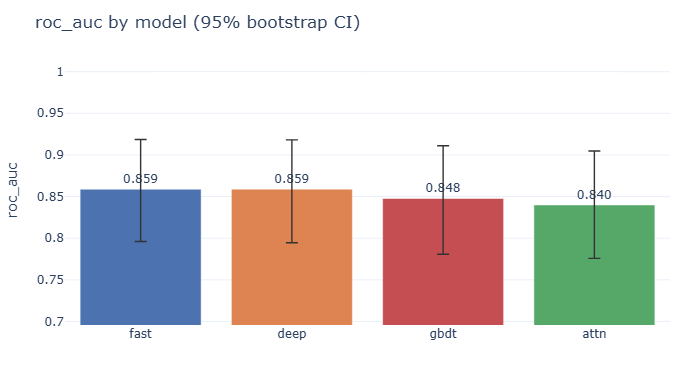

08:28:33 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:33 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:34 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:34 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:34 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp23m610om.


...

08:28:35 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:35 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:35 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:35 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:35 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


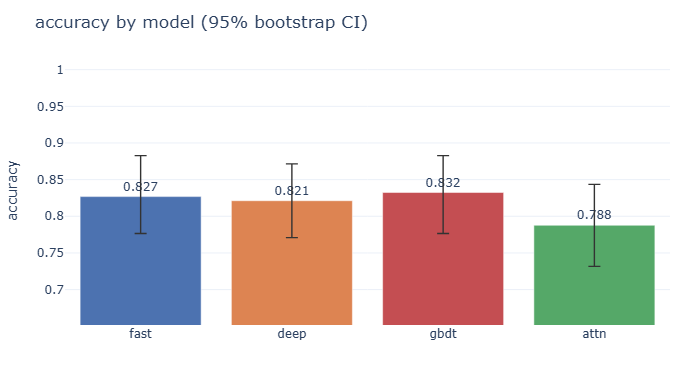

In [5]:
for metric in ("roc_auc", "accuracy"):
    plots.metrics_comparison_fig(metrics, intervals, metric=metric).show()

In [6]:
# Which models fall inside the leader's interval?
leader = max(MODELS, key=lambda n: metrics[n]["roc_auc"])
low, high = intervals[leader]["roc_auc"]

print(f"leader: {leader}  ROC-AUC {metrics[leader]['roc_auc']:.3f}")
print(f"its 95% CI: [{low:.3f}, {high:.3f}]\n")
for name in MODELS:
    value = metrics[name]["roc_auc"]
    inside = value >= low
    print(f"  {name:<5} {value:.3f}  {'inside' if inside else 'OUTSIDE'} the leader's interval")

leader: deep  ROC-AUC 0.859
its 95% CI: [0.795, 0.918]

  fast  0.859  inside the leader's interval
  deep  0.859  inside the leader's interval
  gbdt  0.848  inside the leader's interval
  attn  0.840  inside the leader's interval


---

## 5. ROC and precision-recall

Both curves, all models overlaid. ROC measures ranking independently of the threshold and the
class balance; PR is more sensitive to the minority (survived) class, which is the one a user
of this model actually cares about — so the no-skill baseline sits at the 38% base rate, not
at 0.5.

08:28:35 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:35 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:35 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:35 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:35 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpv56b9py0.


...

08:28:36 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:36 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:36 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:36 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:36 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


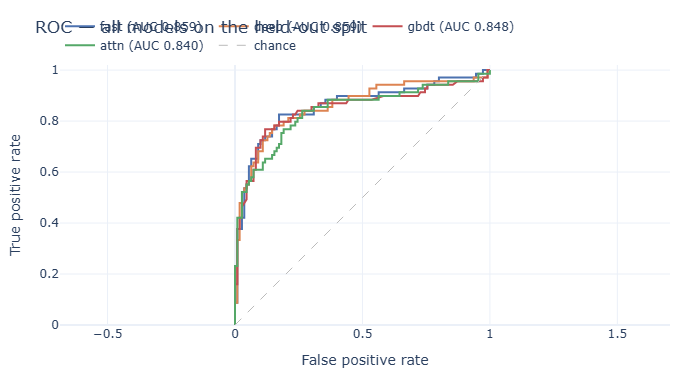

08:28:36 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:36 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:36 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp1fzdm__c.


08:28:36 | INFO    | choreographer.browser_async | Opening browser.


08:28:36 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpqgx514ni.


...

08:28:37 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:37 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:37 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:37 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:37 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


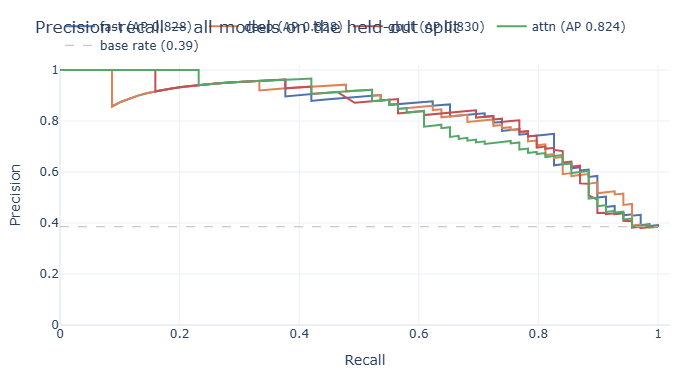

In [7]:
plots.roc_fig(curves, title="ROC — all models on the held-out split").show()
plots.pr_fig(curves, title="Precision-recall — all models on the held-out split").show()

---

## 6. Confusion matrices

Where each model's errors actually fall. Percentages are row-normalised: *of the passengers who
really did survive, what fraction did we catch?*

08:28:37 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:37 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:37 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:37 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:37 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmps1yb9p5h.


...

08:28:39 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:39 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:39 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:39 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:39 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


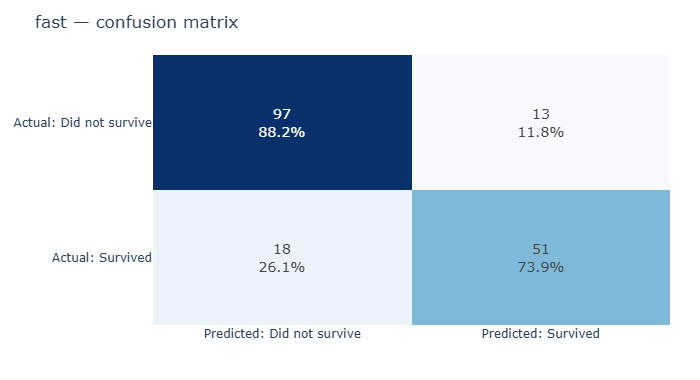

08:28:39 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:39 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:39 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpcjspr46f.


08:28:39 | INFO    | choreographer.browser_async | Opening browser.


08:28:39 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpad081edd.


...

08:28:40 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:40 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:40 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:40 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:40 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


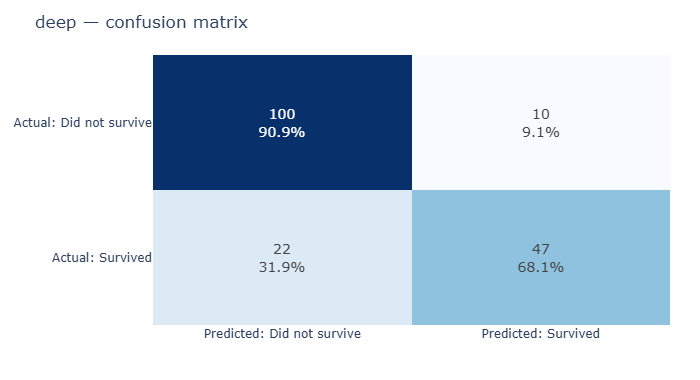

08:28:40 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:40 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:40 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:40 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:40 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmprub0e9_m.


...

08:28:41 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:41 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:41 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:41 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:41 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


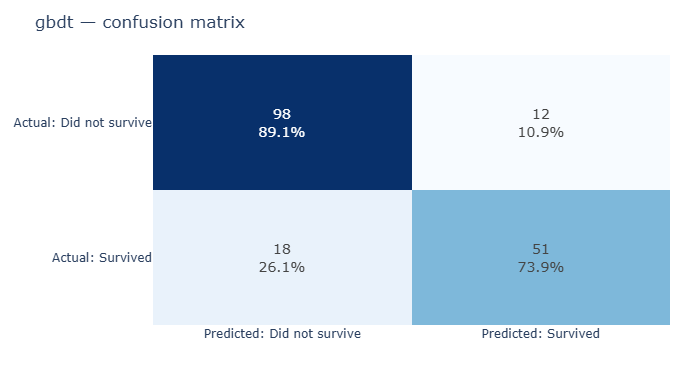

08:28:41 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:41 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:41 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpng4ozno2.


08:28:41 | INFO    | choreographer.browser_async | Opening browser.


08:28:41 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp02purk0o.


...

08:28:43 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:43 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:43 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:43 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:43 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


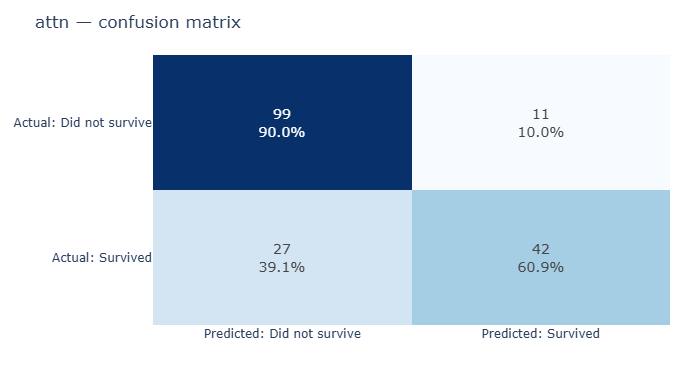

,fast,deep,gbdt,attn
false negatives (missed survivors),18.000,22.000,18.000,27.000
false positives (false hope),13.000,10.000,12.000,11.000
recall,0.739,0.681,0.739,0.609
precision,0.797,0.825,0.810,0.792


In [8]:
for name in MODELS:
    plots.confusion_matrix_fig(
        metrics[name]["confusion_matrix"], title=f"{name} — confusion matrix"
    ).show()

errors = pd.DataFrame(
    {
        name: {
            "false negatives (missed survivors)": metrics[name]["confusion"]["false_negative"],
            "false positives (false hope)": metrics[name]["confusion"]["false_positive"],
            "recall": round(metrics[name]["recall"], 3),
            "precision": round(metrics[name]["precision"], 3),
        }
        for name in MODELS
    }
)
display(errors)

**The models differ in *character*, not in quality.** The ones with more false negatives are
being conservative — they predict fewer survivors, which buys precision and costs recall.
Which behaviour you want depends on whether missing a survivor costs more than a false alarm.
The assignment states no such cost, which is why the threshold stays at 0.5 and the slider in
the app exists to *show* the trade-off rather than to tune it.

---

## 7. The threshold trade-off

Moving the decision threshold trades precision against recall. Note that no threshold is ever
optimised on this data and then reported as a result — that would be selecting on the
evaluation set.

08:28:43 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:43 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:43 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpn0n7gl19.


08:28:43 | INFO    | choreographer.browser_async | Opening browser.


08:28:43 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpkewsuqs7.


...

08:28:44 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:44 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:44 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:44 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:44 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


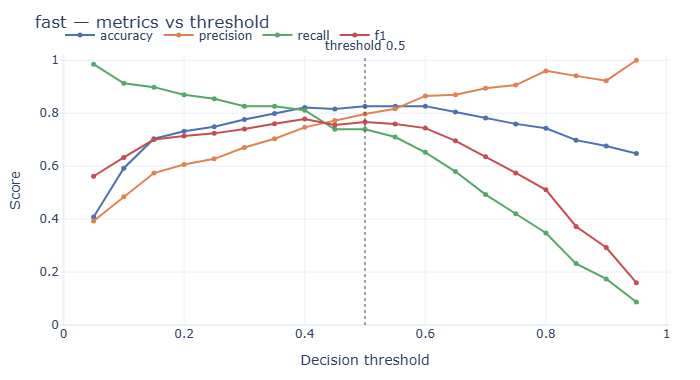

08:28:44 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:44 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:44 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp3gjwdl49.


08:28:44 | INFO    | choreographer.browser_async | Opening browser.


08:28:44 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpqweyohg9.


...

08:28:45 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:45 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:45 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:45 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:45 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


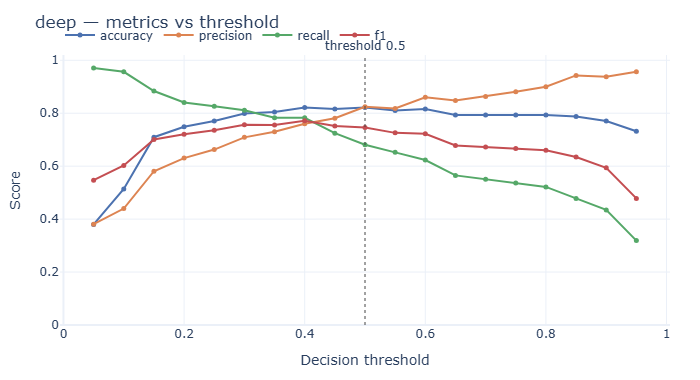

08:28:45 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:45 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:45 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp17vdvcee.


08:28:45 | INFO    | choreographer.browser_async | Opening browser.


08:28:45 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpz57j2hkf.


...

08:28:47 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:47 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:47 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:47 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:47 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


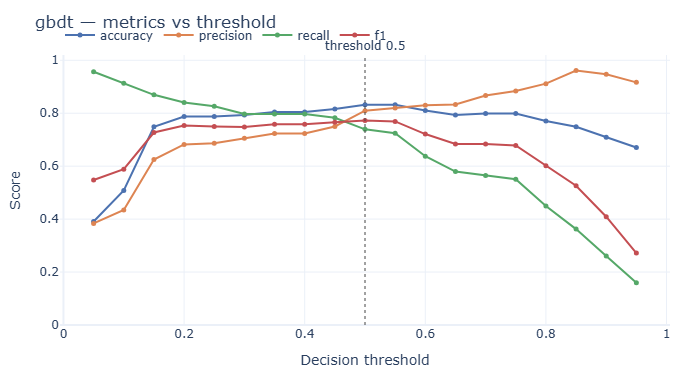

08:28:47 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:47 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:47 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpxi0t24mw.


08:28:47 | INFO    | choreographer.browser_async | Opening browser.


08:28:47 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp1ck71yhw.


...

08:28:48 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:48 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:48 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:48 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:48 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


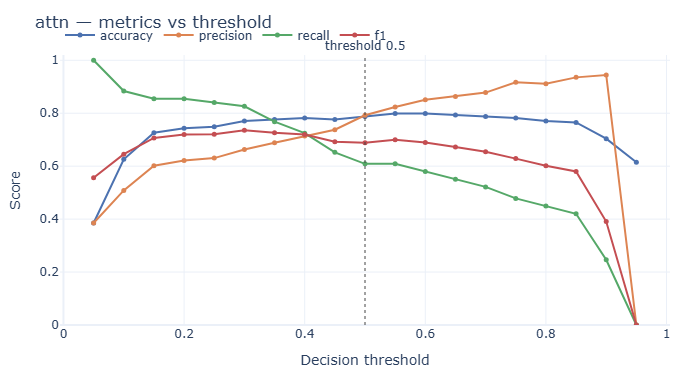

In [9]:
for name in MODELS:
    plots.threshold_sweep_fig(
        curves[name]["threshold_sweep"], 0.5, title=f"{name} — metrics vs threshold"
    ).show()

---

## 8. Calibration

ROC-AUC only measures *ranking*. A model can rank perfectly and still be systematically
over-confident. Calibration compares predicted probability against observed frequency: points
on the diagonal are honest. Marker size is the number of passengers in that bin, so a point
resting on three passengers is visibly less trustworthy than one resting on fifty.

08:28:48 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:48 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:48 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmph0pahlgq.


08:28:48 | INFO    | choreographer.browser_async | Opening browser.


08:28:48 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp__pwolij.


...

08:28:49 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:49 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:49 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:49 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:49 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


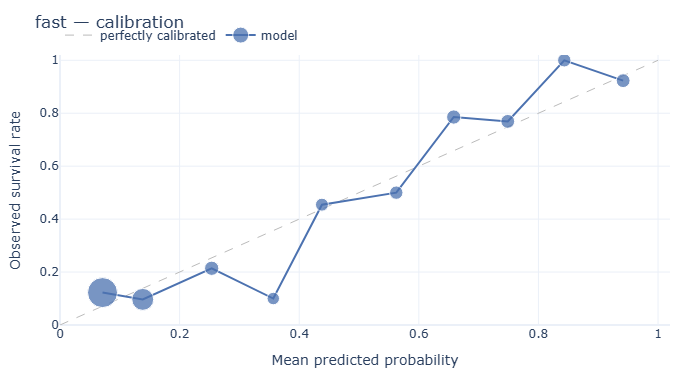

08:28:49 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:49 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:49 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp06y4fdtn.


08:28:49 | INFO    | choreographer.browser_async | Opening browser.


08:28:49 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpqzhjs71j.


...

08:28:51 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:51 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:51 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:51 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:51 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


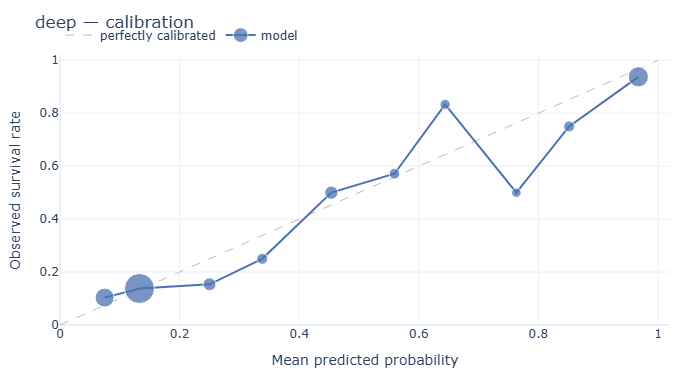

08:28:51 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:51 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:51 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:51 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:51 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


...

08:28:52 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:52 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:52 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:52 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:52 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


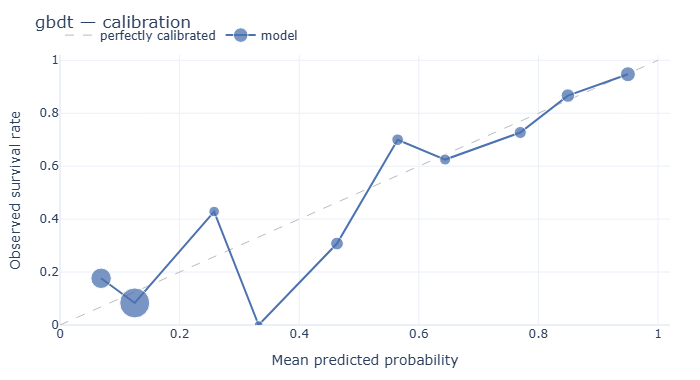

08:28:52 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:52 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:52 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:52 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:52 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp0hoh0ku_.


...

08:28:53 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:53 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:53 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:53 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:53 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


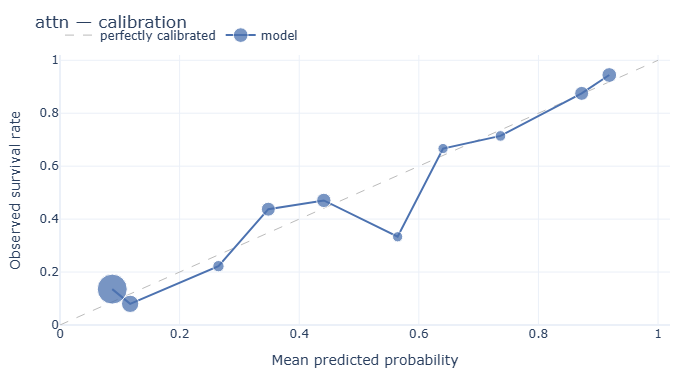

Brier score (lower is better calibrated):
  fast  0.1357
  deep  0.1365
  gbdt  0.1371
  attn  0.1435


In [10]:
for name in MODELS:
    plots.calibration_fig(curves[name]["calibration"], title=f"{name} — calibration").show()

print("Brier score (lower is better calibrated):")
for name in sorted(MODELS, key=lambda n: metrics[n]["brier"]):
    print(f"  {name:<5} {metrics[name]['brier']:.4f}")

---

## 9. What the models actually predict

The distribution of predicted probabilities, split by the true label. Good separation means the
two humps sit apart; overlap in the middle is where the errors live.

08:28:53 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:53 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:53 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpmudylqlz.


08:28:53 | INFO    | choreographer.browser_async | Opening browser.


08:28:53 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpi37gfs45.


...

08:28:55 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:55 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:55 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:55 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:55 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


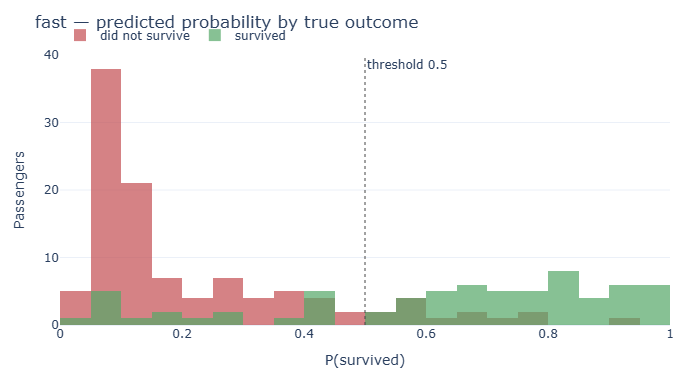

08:28:55 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:55 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:55 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:55 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:55 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp81ryozur.


...

08:28:56 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:56 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:56 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:56 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:56 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


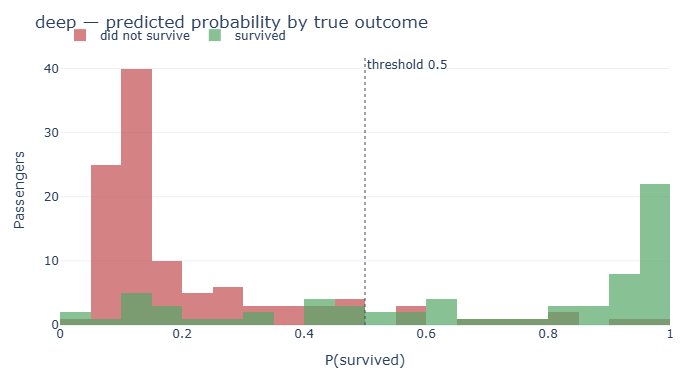

08:28:56 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:56 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:56 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp8dq9xqbl.


08:28:56 | INFO    | choreographer.browser_async | Opening browser.


08:28:56 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpx3xoj5t3.


...

08:28:57 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:57 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:57 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:57 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:57 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


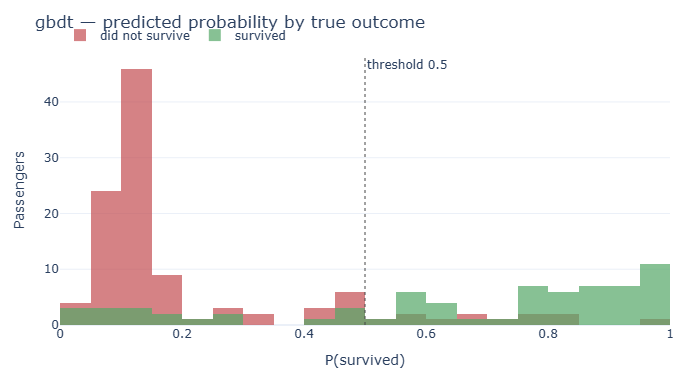

08:28:57 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:57 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:57 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:57 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:57 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp9n8m11t5.


...

08:28:59 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:28:59 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:28:59 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:28:59 | INFO    | kaleido.kaleido | Cancelling tasks.


08:28:59 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


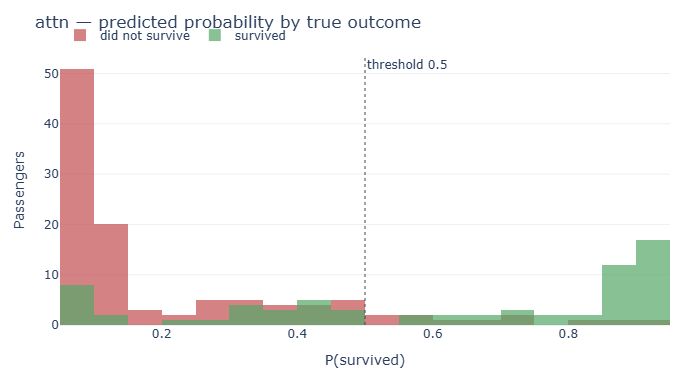

In [11]:
for name in MODELS:
    plots.prob_histogram_fig(
        curves[name]["probabilities"],
        curves[name]["y_true"],
        0.5,
        title=f"{name} — predicted probability by true outcome",
    ).show()

---

## 10. Training curves

Loss per epoch for the PyTorch models. The validation series is the **10% carve-out from inside
the training split**, never the held-out set — that is what makes early stopping legitimate.
The marked epoch is where the best weights were taken from.

08:28:59 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:28:59 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:28:59 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpcvn7cc51.


08:28:59 | INFO    | choreographer.browser_async | Opening browser.


08:28:59 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmp9a4ny802.


...

08:29:00 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:29:00 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:29:00 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:29:00 | INFO    | kaleido.kaleido | Cancelling tasks.


08:29:00 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


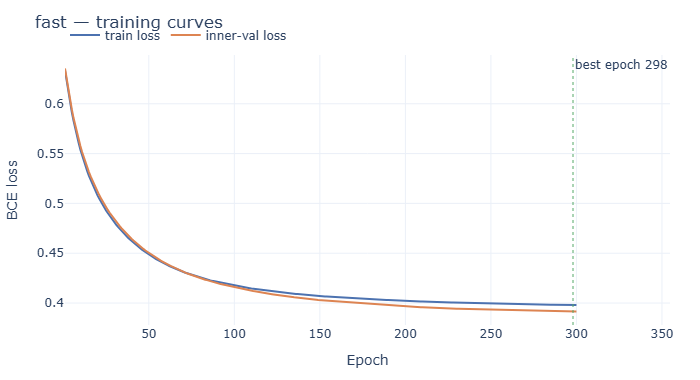

08:29:00 | INFO    | choreographer.browsers.chromium | Chromium init'ed with kwargs {}


08:29:00 | INFO    | choreographer.browsers.chromium | Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe


08:29:00 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpmz0kezny.


08:29:00 | INFO    | choreographer.browser_async | Opening browser.


08:29:00 | INFO    | choreographer.utils._tmpfile | Temp directory created: C:\Users\Lenovo\AppData\Local\Temp\tmpwrt8stat.


...

08:29:01 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:29:01 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:29:01 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:29:01 | INFO    | kaleido.kaleido | Cancelling tasks.


08:29:01 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


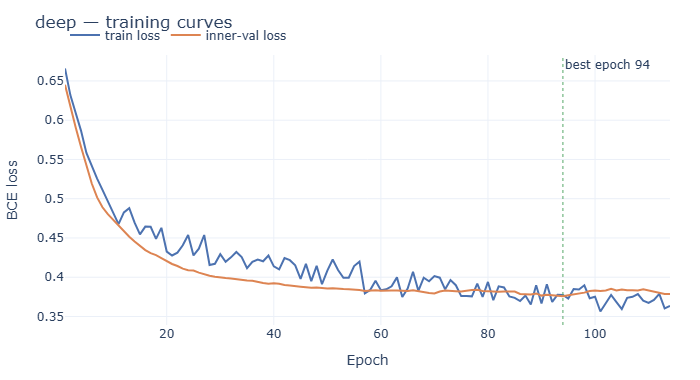

08:29:01 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:29:01 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:29:01 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:29:01 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:29:01 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


...

08:29:03 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


08:29:03 | INFO    | choreographer.utils._tmpfile | TemporaryDirectory.cleanup() worked.


08:29:03 | INFO    | choreographer.utils._tmpfile | shutil.rmtree worked.


08:29:03 | INFO    | kaleido.kaleido | Cancelling tasks.


08:29:03 | INFO    | kaleido.kaleido | Exiting Kaleido/Choreo.


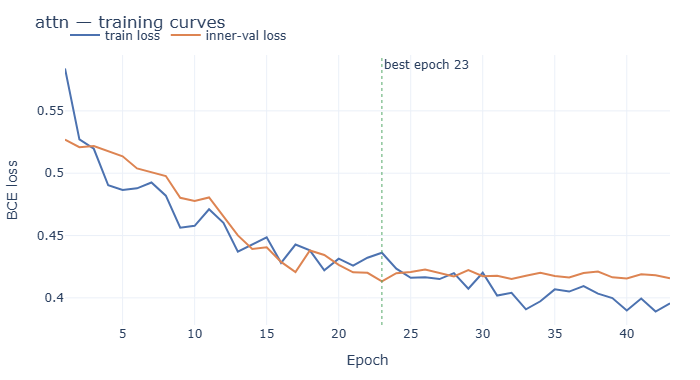

attn: 43 epochs run, best at 23, early stop = True, 5.46s


In [12]:
for name in MODELS:
    directory = bundle_dir(paths.artifacts, name, registry["models"].get(name))
    history_path = directory / "history.json"
    if not history_path.is_file():
        continue
    history = json.loads(history_path.read_text(encoding="utf-8"))
    if not history.get("epochs"):
        print(f"{name}: no epoch history (not a neural network)")
        continue

    plots.training_curves_fig(history, title=f"{name} — training curves").show()
    print(
        f"{name}: {history['n_epochs_run']} epochs run, best at {history['best_epoch']}, "
        f"early stop = {history['stopped_early']}, {history['train_seconds']}s"
    )

---

## 11. Cost

Accuracy is not the only axis. These models differ by **216x in parameter count** — so what did
the extra capacity buy?

In [13]:
cost = []
for name in MODELS:
    directory = bundle_dir(paths.artifacts, name, registry["models"].get(name))
    config = json.loads((directory / "model_config.json").read_text(encoding="utf-8"))
    saved_metrics = json.loads((directory / "metrics.json").read_text(encoding="utf-8"))
    cost.append(
        {
            "model": name,
            "params": config["n_params"],
            "ms_per_1k_rows": saved_metrics["inference_ms_per_1k_rows"],
            "roc_auc": round(metrics[name]["roc_auc"], 4),
        }
    )

cost_df = pd.DataFrame(cost).set_index("model").sort_values("params")
smallest = cost_df.index[0]
cost_df["params_vs_smallest"] = (cost_df["params"] / cost_df.loc[smallest, "params"]).round(0)
cost_df["roc_auc_vs_smallest"] = (cost_df["roc_auc"] - cost_df.loc[smallest, "roc_auc"]).round(4)
display(cost_df)

biggest = cost_df["params_vs_smallest"].max()
print(f"\nLargest model is {biggest:.0f}x the parameters of `{smallest}`")
print(f"and scores {cost_df['roc_auc_vs_smallest'].min():+.4f} ROC-AUC against it.")

,params,ms_per_1k_rows,roc_auc,params_vs_smallest,roc_auc_vs_smallest
model,,,,,
fast,34,1.7704,0.8588,1.0,0.0000
gbdt,1084,17.8039,0.8477,32.0,-0.0111
deep,1281,2.2436,0.8589,38.0,0.0001
attn,7361,22.9799,0.8399,216.0,-0.0189



Largest model is 216x the parameters of `fast`
and scores -0.0189 ROC-AUC against it.


---

## 12. Conclusion — which model would I ship?

**`fast`, the 34-parameter logistic regression.**

Every model's point estimate falls inside every other model's 95% confidence interval, so the
ordering in the results table is not a real ranking — the intervals are several times wider
than the spread between best and worst. Given that, the tie-breaker is cost: `fast` matches the
best measured ROC-AUC, trains in under two seconds, runs fastest, and its coefficients can be
read directly.

Choosing the transformer would mean paying **216× the parameters** for a difference this data
cannot resolve.

**This was the predicted outcome, not a disappointment.** [`eda.ipynb`](eda.ipynb) established
the expectation band (ROC-AUC 0.86–0.89) with classical cross-validation *before* any PyTorch
was written, and showed that the fold-to-fold spread (0.080) already exceeded the gap between
any two models. With 712 training rows, 9 features and dominant low-order signal — sex, then
class, then age — there was very little left for extra capacity to learn.

The deliverable is the comparison with its uncertainty, not a winner.

---

*Reproduce with `python train.py --model all` (~80 s on CPU), then re-run this notebook.*